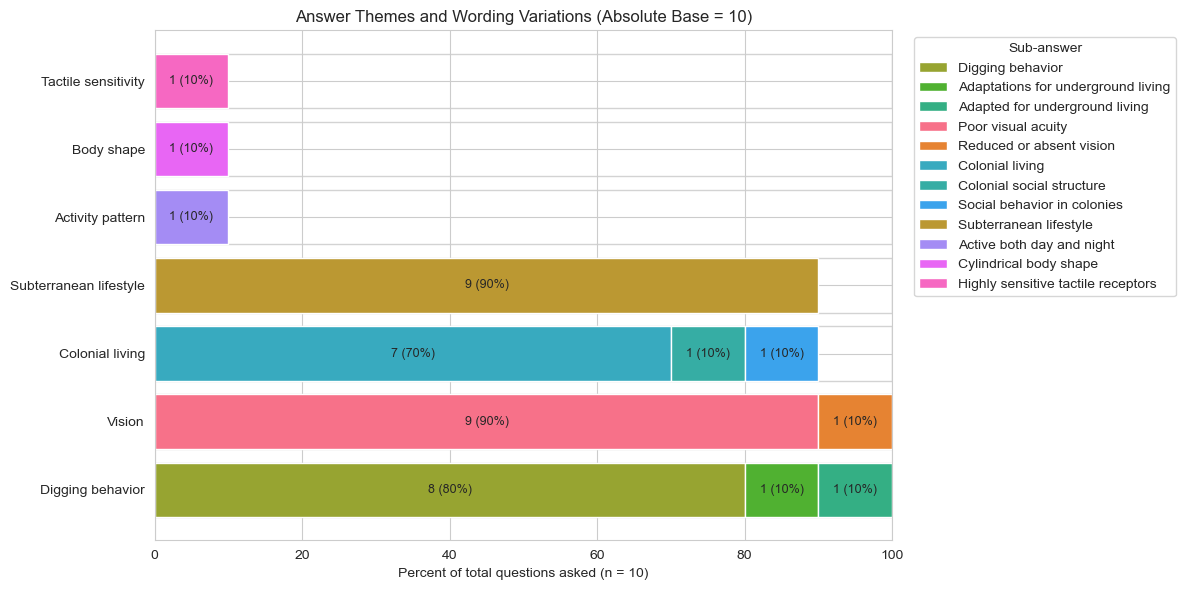

In [12]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

TOTAL_ASKS = 10  # fixed base (10 asks = 100%)

rows = [
    ("Vision", "Poor visual acuity", 9),
    ("Vision", "Reduced or absent vision", 1),

    ("Subterranean lifestyle", "Subterranean lifestyle", 9),

    ("Digging behavior", "Digging behavior", 8),
    ("Digging behavior", "Adaptations for underground living", 1),
    ("Digging behavior", "Adapted for underground living", 1),

    ("Colonial living", "Colonial social structure", 1),
    ("Colonial living", "Colonial living", 7),
    ("Colonial living", "Social behavior in colonies", 1),

    ("Activity pattern", "Active both day and night", 1),

    ("Body shape", "Cylindrical body shape", 1),

    ("Tactile sensitivity", "Highly sensitive tactile receptors", 1),
]

df = pd.DataFrame(rows, columns=["Theme", "Sub-answer", "Count"])
df["Percent"] = df["Count"] / TOTAL_ASKS * 100

# --- Order themes by absolute % (i.e., total mentions / TOTAL_ASKS) ---
theme_totals = df.groupby("Theme", as_index=False)["Percent"].sum()
theme_order = theme_totals.sort_values("Percent", ascending=False)["Theme"].tolist()

# --- Give EVERY sub-answer its own unique color (no repeats) ---
subanswers = df["Sub-answer"].unique().tolist()
palette = sns.color_palette("husl", n_colors=len(subanswers))  # distinct colors even for many categories
color_map = dict(zip(subanswers, palette))

# Style
sns.set_style("whitegrid")

fig, ax = plt.subplots(figsize=(12, 6))

for theme in theme_order:
    left = 0.0
    theme_df = df[df["Theme"] == theme]

    # (optional) keep segments ordered by size within each theme
    theme_df = theme_df.sort_values("Percent", ascending=False)

    for _, r in theme_df.iterrows():
        ax.barh(
            y=theme,
            width=r["Percent"],
            left=left,
            color=color_map[r["Sub-answer"]],
            edgecolor="white",
            linewidth=1,
            label=r["Sub-answer"],
        )

        # Label segments that are readable (>= 10% = at least 1 mention)
        if r["Percent"] >= 10:
            ax.text(
                left + r["Percent"] / 2,
                theme,
                f'{int(r["Count"])} ({r["Percent"]:.0f}%)',
                ha="center",
                va="center",
                fontsize=9,
            )

        left += r["Percent"]

    # Outline the full 100% width so short bars (e.g., 10%) are obvious
    ax.barh(theme, 100, color="none", edgecolor="lightgray", linewidth=1, zorder=0)

ax.set_xlim(0, 100)
ax.set_xlabel(f"Percent of total questions asked (n = {TOTAL_ASKS})")
ax.set_ylabel("")
ax.set_title("Answer Themes and Wording Variations (Absolute Base = 10)")

# Legend without duplicates
handles, labels = ax.get_legend_handles_labels()
unique = {}
for h, l in zip(handles, labels):
    if l not in unique:
        unique[l] = h

ax.legend(
    unique.values(),
    unique.keys(),
    bbox_to_anchor=(1.02, 1),
    loc="upper left",
    title="Sub-answer",
    frameon=True,
)

plt.tight_layout()
plt.savefig("fig/fig_testcase1.png", dpi=600, bbox_inches="tight")
plt.show()


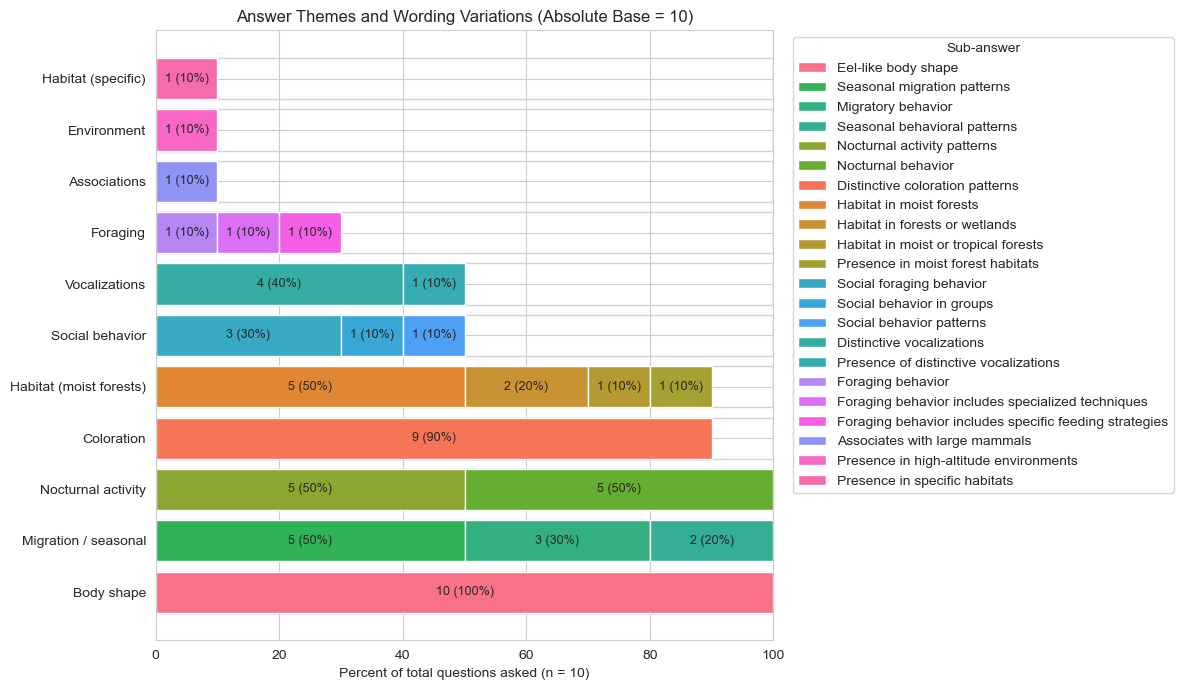

In [13]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

TOTAL_ASKS = 10  # fixed base (10 asks = 100%)

rows = [
    ("Body shape", "Eel-like body shape", 10),

    ("Coloration", "Distinctive coloration patterns", 9),

    ("Habitat (moist forests)", "Habitat in moist forests", 5),
    ("Habitat (moist forests)", "Habitat in forests or wetlands", 2),
    ("Habitat (moist forests)", "Habitat in moist or tropical forests", 1),
    ("Habitat (moist forests)", "Presence in moist forest habitats", 1),

    ("Nocturnal activity", "Nocturnal activity patterns", 5),
    ("Nocturnal activity", "Nocturnal behavior", 5),

    ("Migration / seasonal", "Seasonal migration patterns", 5),
    ("Migration / seasonal", "Migratory behavior", 3),
    ("Migration / seasonal", "Seasonal behavioral patterns", 2),

    ("Vocalizations", "Distinctive vocalizations", 4),
    ("Vocalizations", "Presence of distinctive vocalizations", 1),

    ("Social behavior", "Social foraging behavior", 3),
    ("Social behavior", "Social behavior in groups", 1),
    ("Social behavior", "Social behavior patterns", 1),

    ("Associations", "Associates with large mammals", 1),

    ("Foraging", "Foraging behavior", 1),
    ("Foraging", "Foraging behavior includes specialized techniques", 1),
    ("Foraging", "Foraging behavior includes specific feeding strategies", 1),

    ("Environment", "Presence in high-altitude environments", 1),

    ("Habitat (specific)", "Presence in specific habitats", 1),
]

df = pd.DataFrame(rows, columns=["Theme", "Sub-answer", "Count"])
df["Percent"] = df["Count"] / TOTAL_ASKS * 100

# Order themes by absolute % (total mentions / TOTAL_ASKS)
theme_totals = df.groupby("Theme", as_index=False)["Percent"].sum()
theme_order = theme_totals.sort_values("Percent", ascending=False)["Theme"].tolist()

# Unique color per sub-answer (no repeats)
subanswers = df["Sub-answer"].unique().tolist()
palette = sns.color_palette("husl", n_colors=len(subanswers))
color_map = dict(zip(subanswers, palette))

sns.set_style("whitegrid")
fig, ax = plt.subplots(figsize=(12, 7))

for theme in theme_order:
    left = 0.0
    theme_df = df[df["Theme"] == theme].sort_values("Percent", ascending=False)

    for _, r in theme_df.iterrows():
        ax.barh(
            y=theme,
            width=r["Percent"],
            left=left,
            color=color_map[r["Sub-answer"]],
            edgecolor="white",
            linewidth=1,
            label=r["Sub-answer"],
        )

        # label segments that are readable (>= 10% = at least 1 mention)
        if r["Percent"] >= 10:
            ax.text(
                left + r["Percent"] / 2,
                theme,
                f'{int(r["Count"])} ({r["Percent"]:.0f}%)',
                ha="center",
                va="center",
                fontsize=9,
            )

        left += r["Percent"]

    # Outline full 100% width so short bars are obvious
    ax.barh(theme, 100, color="none", edgecolor="lightgray", linewidth=1, zorder=0)

ax.set_xlim(0, 100)
ax.set_xlabel(f"Percent of total questions asked (n = {TOTAL_ASKS})")
ax.set_ylabel("")
ax.set_title("Answer Themes and Wording Variations (Absolute Base = 10)")

# Legend without duplicates (can get long; keep if you want)
handles, labels = ax.get_legend_handles_labels()
unique = {}
for h, l in zip(handles, labels):
    if l not in unique:
        unique[l] = h

ax.legend(
    unique.values(),
    unique.keys(),
    bbox_to_anchor=(1.02, 1),
    loc="upper left",
    title="Sub-answer",
    frameon=True,
)

plt.tight_layout()
plt.savefig("fig/fig_testcase2.png", dpi=600, bbox_inches="tight")
plt.show()

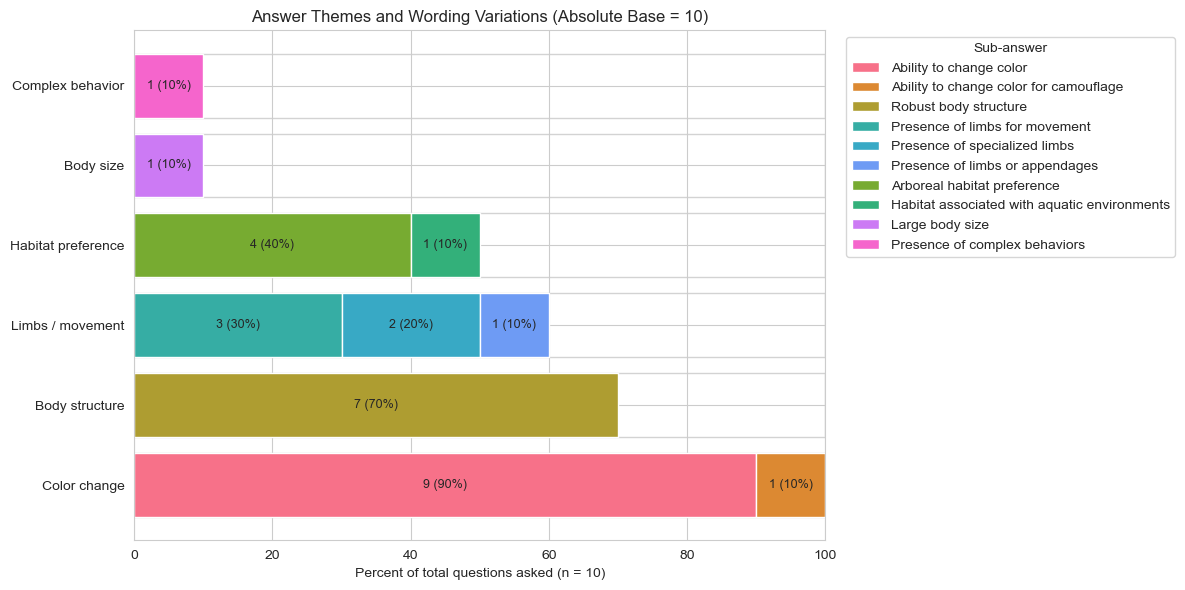

In [14]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

TOTAL_ASKS = 10  # fixed base (10 asks = 100%)

rows = [
    ("Color change", "Ability to change color", 9),
    ("Color change", "Ability to change color for camouflage", 1),

    ("Body structure", "Robust body structure", 7),

    ("Habitat preference", "Arboreal habitat preference", 4),
    ("Habitat preference", "Habitat associated with aquatic environments", 1),

    ("Limbs / movement", "Presence of limbs for movement", 3),
    ("Limbs / movement", "Presence of specialized limbs", 2),
    ("Limbs / movement", "Presence of limbs or appendages", 1),

    ("Body size", "Large body size", 1),

    ("Complex behavior", "Presence of complex behaviors", 1),
]

df = pd.DataFrame(rows, columns=["Theme", "Sub-answer", "Count"])
df["Percent"] = df["Count"] / TOTAL_ASKS * 100

# Order themes by absolute percent (largest total first)
theme_totals = df.groupby("Theme", as_index=False)["Percent"].sum()
theme_order = theme_totals.sort_values("Percent", ascending=False)["Theme"].tolist()

# Unique color per sub-answer
subanswers = df["Sub-answer"].unique().tolist()
palette = sns.color_palette("husl", n_colors=len(subanswers))
color_map = dict(zip(subanswers, palette))

sns.set_style("whitegrid")
fig, ax = plt.subplots(figsize=(12, 6))

for theme in theme_order:
    left = 0.0
    theme_df = df[df["Theme"] == theme].sort_values("Percent", ascending=False)

    for _, r in theme_df.iterrows():
        ax.barh(
            y=theme,
            width=r["Percent"],
            left=left,
            color=color_map[r["Sub-answer"]],
            edgecolor="white",
            linewidth=1,
            label=r["Sub-answer"],
        )

        # Label readable segments (>=10% = at least 1 mention)
        if r["Percent"] >= 10:
            ax.text(
                left + r["Percent"] / 2,
                theme,
                f'{int(r["Count"])} ({r["Percent"]:.0f}%)',
                ha="center",
                va="center",
                fontsize=9,
            )

        left += r["Percent"]

    # Show full 100% reference width
    ax.barh(theme, 100, color="none", edgecolor="lightgray", linewidth=1, zorder=0)

ax.set_xlim(0, 100)
ax.set_xlabel(f"Percent of total questions asked (n = {TOTAL_ASKS})")
ax.set_ylabel("")
ax.set_title("Answer Themes and Wording Variations (Absolute Base = 10)")

# Clean legend (no duplicates)
handles, labels = ax.get_legend_handles_labels()
unique = {}
for h, l in zip(handles, labels):
    if l not in unique:
        unique[l] = h

ax.legend(
    unique.values(),
    unique.keys(),
    bbox_to_anchor=(1.02, 1),
    loc="upper left",
    title="Sub-answer",
    frameon=True,
)

plt.tight_layout()
plt.savefig("fig/fig_testcase3.png", dpi=600, bbox_inches="tight")
plt.show()

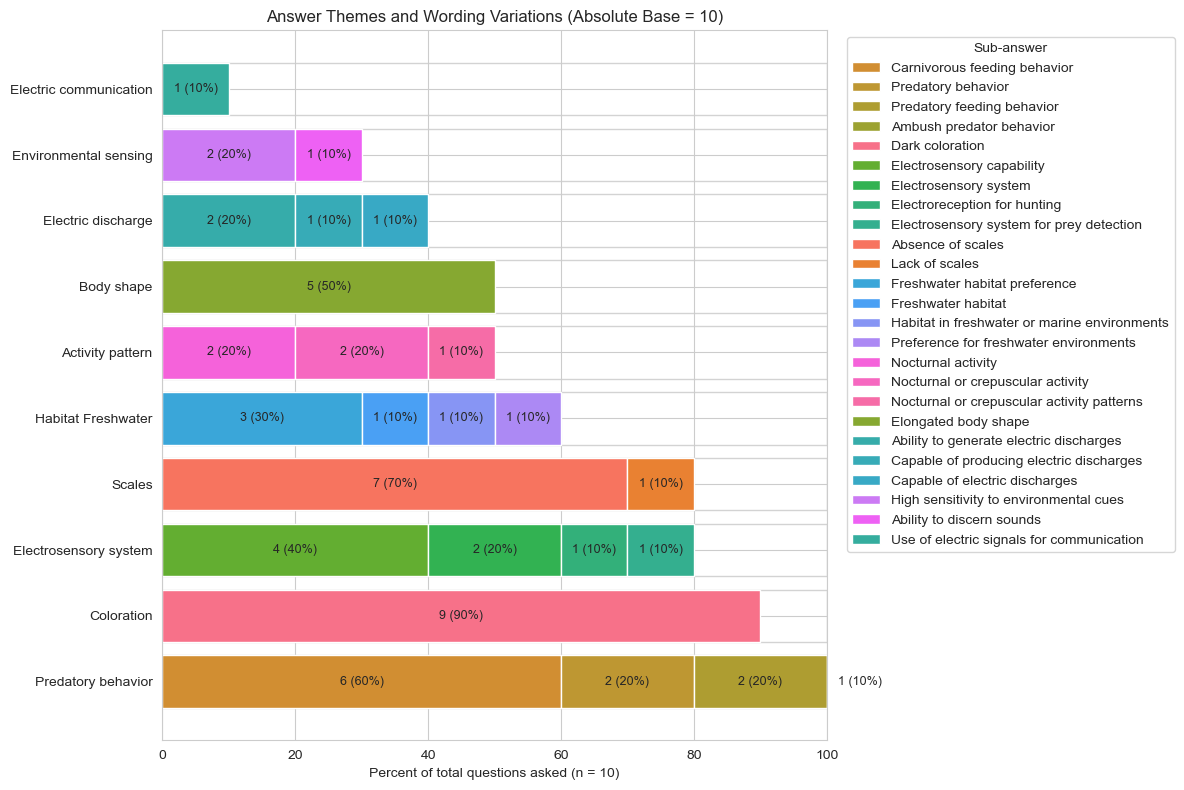

In [15]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

TOTAL_ASKS = 10  # fixed base

rows = [
    ("Coloration", "Dark coloration", 9),

    ("Scales", "Absence of scales", 7),
    ("Scales", "Lack of scales", 1),

    ("Predatory behavior", "Carnivorous feeding behavior", 6),
    ("Predatory behavior", "Predatory behavior", 2),
    ("Predatory behavior", "Predatory feeding behavior", 2),
    ("Predatory behavior", "Ambush predator behavior", 1),

    ("Body shape", "Elongated body shape", 5),

    ("Electrosensory system", "Electrosensory capability", 4),
    ("Electrosensory system", "Electrosensory system", 2),
    ("Electrosensory system", "Electroreception for hunting", 1),
    ("Electrosensory system", "Electrosensory system for prey detection", 1),

    ("Electric communication", "Use of electric signals for communication", 1),

    ("Electric discharge", "Ability to generate electric discharges", 2),
    ("Electric discharge", "Capable of producing electric discharges", 1),
    ("Electric discharge", "Capable of electric discharges", 1),

    ("Habitat Freshwater", "Freshwater habitat preference", 3),
    ("Habitat Freshwater", "Freshwater habitat", 1),
    ("Habitat Freshwater", "Habitat in freshwater or marine environments", 1),
    ("Habitat Freshwater", "Preference for freshwater environments", 1),

    ("Environmental sensing", "High sensitivity to environmental cues", 2),
    ("Environmental sensing", "Ability to discern sounds", 1),

    ("Activity pattern", "Nocturnal activity", 2),
    ("Activity pattern", "Nocturnal or crepuscular activity", 2),
    ("Activity pattern", "Nocturnal or crepuscular activity patterns", 1),
]

df = pd.DataFrame(rows, columns=["Theme", "Sub-answer", "Count"])
df["Percent"] = df["Count"] / TOTAL_ASKS * 100

# Order themes by total percentage (descending)
theme_totals = df.groupby("Theme", as_index=False)["Percent"].sum()
theme_order = theme_totals.sort_values("Percent", ascending=False)["Theme"].tolist()

# Unique color per sub-answer
subanswers = df["Sub-answer"].unique().tolist()
palette = sns.color_palette("husl", n_colors=len(subanswers))
color_map = dict(zip(subanswers, palette))

sns.set_style("whitegrid")
fig, ax = plt.subplots(figsize=(12, 8))

for theme in theme_order:
    left = 0.0
    theme_df = df[df["Theme"] == theme].sort_values("Percent", ascending=False)

    for _, r in theme_df.iterrows():
        ax.barh(
            y=theme,
            width=r["Percent"],
            left=left,
            color=color_map[r["Sub-answer"]],
            edgecolor="white",
            linewidth=1,
            label=r["Sub-answer"],
        )

        # Label segments that are big enough to read
        if r["Percent"] >= 10:
            ax.text(
                left + r["Percent"] / 2,
                theme,
                f'{int(r["Count"])} ({r["Percent"]:.0f}%)',
                ha="center",
                va="center",
                fontsize=9,
            )

        left += r["Percent"]

    # Outline the full 100% reference width
    ax.barh(theme, 100, color="none", edgecolor="lightgray", linewidth=1, zorder=0)

ax.set_xlim(0, 100)
ax.set_xlabel(f"Percent of total questions asked (n = {TOTAL_ASKS})")
ax.set_ylabel("")
ax.set_title("Answer Themes and Wording Variations (Absolute Base = 10)")

# Clean legend (no duplicates)
handles, labels = ax.get_legend_handles_labels()
unique = {}
for h, l in zip(handles, labels):
    if l not in unique:
        unique[l] = h

ax.legend(
    unique.values(),
    unique.keys(),
    bbox_to_anchor=(1.02, 1),
    loc="upper left",
    title="Sub-answer",
    frameon=True,
)

plt.tight_layout()
plt.savefig("fig/fig_testcase4.png", dpi=600, bbox_inches="tight")
plt.show()